# Quantitative Evaluation of Explainable Deep Reinforcement Learning (CQL) in Dairy Supply Chain Optimization


## Setup Device


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Ignore Warning


In [2]:
import warnings

warnings.filterwarnings("ignore")

## Creating Directory


In [3]:
from pathlib import Path

# Define your directory path
dir_path = Path("./plots")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

# Define your directory path
dir_path = Path("./results")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

## Research-Grade Visualization


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Load Data


In [5]:
import os
import kagglehub
import pandas as pd

print("Loading data...")
path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
data_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_path)
print("Data loading was successful...")

Loading data...
Data loading was successful...


In [6]:
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_cols}")

Rows: 122983
Columns: 24


## Environment Formulation & Offline Data Engineering


### Temporal Feature Engineering


In [7]:
print("Processing temporal features...")

# Convert date columns to datetime objects dates are in DD-MM-YYYY format
date_cols = ["Date", "Production Date", "Expiration Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

# Calculate 'Days to Expiration'
# This is the exact number of days left from the current transaction 'Date' until the product spoils.
df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days

# Drop rows where expiration is negative (already spoiled before the record date) or where dates are missing due to parsing errors.
df = df[df["Days_to_Expiration"] >= 0].copy()

# Calculate Age of product since production
df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

print("Processing temporal features was successful...")

Processing temporal features...
Processing temporal features was successful...


### Age-Structured Inventory Matrix (FIFO)


In [8]:
print("Building FIFO age-structured matrices...")
# In Deep RL, the agent needs a fixed-size vector to understand inventory age.
# We will create a vector up to 'MAX_SHELF_LIFE' (e.g., 30 days).
# Bins: [Expiring in 0-2 days, 3-5 days, ..., 20+ days]

MAX_SHELF_LIFE = 30  # Cap for the maximum days we track individually

# Pivot the data to create a state vector for each Product ID on each Date
# We group by Date and Product ID, and sum the Quantity in Stock for each expiration day.
fifo_matrix = df.pivot_table(
    index=["Date", "Product ID"],
    columns="Days_to_Expiration",
    values="Quantity in Stock (liters/kg)",
    aggfunc="sum",
    fill_value=0,
)

# Truncate and group columns beyond MAX_SHELF_LIFE to prevent infinite state space expansion
cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]

if cols_to_group:
    fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
    fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

# Rename columns for clarity in the RL State Vector
fifo_matrix.columns = [
    f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
    for col in fifo_matrix.columns
]

print(f"Created FIFO matrix with shape: {fifo_matrix.shape}")

Building FIFO age-structured matrices...
Created FIFO matrix with shape: (56546, 32)


### Multicollinearity Detection


In [9]:
import numpy as np

print("Analyzing Multicollinearity for XAI ROAR/PI evaluation...")

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr().abs()

# Create a mask to ignore the diagonal and the lower triangle (to avoid duplicate pairs)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Set a threshold for identifying highly collinear features
COLLINEAR_THRESHOLD = 0.85

# Find index pairs with correlation above the threshold
collinear_pairs = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i + 1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > COLLINEAR_THRESHOLD
]

print(f"\nHighly Collinear Feature Pairs (Threshold > {COLLINEAR_THRESHOLD}):")

for feat1, feat2, corr_val in collinear_pairs:
    print(f"[{corr_val:.3f}] {feat1} <--> {feat2}")

Analyzing Multicollinearity for XAI ROAR/PI evaluation...

Highly Collinear Feature Pairs (Threshold > 0.85):
[0.988] Price per Unit <--> Price per Unit (sold)


## State & Action Formulation


### Create the RL Environment DataFrame


In [10]:
rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")
rl_df.fillna(0, inplace=True)
print("Shape:", rl_df.shape)

Shape: (60035, 58)


### Encode Categorical Variables


In [11]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Neural networks require numeric inputs. We encode string categories into integers.
print("Encoding categorical variables...")
categorical_cols = [
    "Location",
    "Farm Size",
    "Product Name",
    "Brand",
    "Storage Condition",
    "Sales Channel",
]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    rl_df[col] = le.fit_transform(rl_df[col].astype(str))
    encoders[col] = le

Encoding categorical variables...


### Define State (S) Features


In [12]:
# The state represents the "observation" the agent sees before making a decision.
state_cols = [
    "Location",
    "Total Land Area (acres)",
    "Number of Cows",
    "Farm Size",
    "Product ID",
    "Product Name",
    "Brand",
    "Shelf Life (days)",
    "Storage Condition",
    "Quantity in Stock (liters/kg)",
    "Minimum Stock Threshold (liters/kg)",
    "Price per Unit",  # Base cost (Environmental constraint)
    "Days_to_Expiration",
    "Product_Age_Days",
] + list(fifo_matrix.columns)  # Append the dynamic age-structured inventory

print(f"State vector comprises {len(state_cols)} dimensions.")

State vector comprises 46 dimensions.


### Define Action (A) Features


In [13]:
# As modeled in the literature, we use a continuous action space controlling dynamic pricing and inventory simultaneously.
action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]
print(f"Action vector comprises {len(action_cols)} dimensions.")

Action vector comprises 2 dimensions.


### Extract and Scale the Matrices


In [14]:
# Deep RL algorithms require standardized inputs (Mean=0, Std=1) to prevent exploding gradients and ensure stable convergence.
print("\nScaling State and Action matrices...")
scaler_S = StandardScaler()
scaler_A = StandardScaler()

# Extract raw matrices
S_raw = rl_df[state_cols].values
A_raw = rl_df[action_cols].values

# Fit and transform
S_matrix = scaler_S.fit_transform(S_raw)
A_matrix = scaler_A.fit_transform(A_raw)

print(f"-> State Space (S) shape: {S_matrix.shape}")
print(f"-> Action Space (A) shape: {A_matrix.shape}")

# Store the final dataframe for the Reward engineering step
rl_df_final = rl_df.copy()


Scaling State and Action matrices...
-> State Space (S) shape: (60035, 46)
-> Action Space (A) shape: (60035, 2)


## Reward Engineering & Shaping


### Base Financial Sub-Rewards (Multi-Objective Decomposition)


In [15]:
df_reward = rl_df_final.copy()
print("Calculating financial sub-rewards...")

# A. Gross Profit: Revenue minus the baseline cost of the goods sold
rl_df_final["Gross_Profit"] = rl_df_final["Approx. Total Revenue(INR)"] - (
    rl_df_final["Quantity Sold (liters/kg)"] * rl_df_final["Price per Unit"]
)

# B. Waste Penalty
waste_col = (
    "Stock_Expiring_in_0_Days"
    if "Stock_Expiring_in_0_Days" in rl_df_final.columns
    else "Stock_Expiring_in_1_Days"
)
rl_df_final["Waste_Penalty"] = (
    rl_df_final[waste_col] * rl_df_final["Price per Unit"] * 1.5
)

# C. Holding Cost
rl_df_final["Holding_Cost"] = (
    rl_df_final["Quantity in Stock (liters/kg)"] * rl_df_final["Price per Unit"] * 0.05
)

# D. Stockout Penalty
rl_df_final["Stockout_Penalty"] = np.where(
    rl_df_final["Quantity in Stock (liters/kg)"]
    < rl_df_final["Minimum Stock Threshold (liters/kg)"],
    (
        rl_df_final["Minimum Stock Threshold (liters/kg)"]
        - rl_df_final["Quantity in Stock (liters/kg)"]
    )
    * rl_df_final["Price per Unit"]
    * 2.0,
    0,
)

Calculating financial sub-rewards...


### Aggregating the Raw Reward


In [16]:
print("Aggregating Raw Reward...")
rl_df_final["Raw_Reward"] = (
    rl_df_final["Gross_Profit"]
    - rl_df_final["Waste_Penalty"]
    - rl_df_final["Holding_Cost"]
    - rl_df_final["Stockout_Penalty"]
)
print("Aggregating Raw Reward successfully...")

Aggregating Raw Reward...
Aggregating Raw Reward successfully...


### Preference As Reward (PAR) Bounding


In [17]:
print("Applying Preference As Reward (PAR) bounding...")

r_median = rl_df_final["Raw_Reward"].median()
r_std = rl_df_final["Raw_Reward"].std()


def par_transform(r, ref, std, k=2.0):
    return 2 / (1 + np.exp(-k * (r - ref) / std)) - 1


rl_df_final["Bounded_Reward_PAR"] = par_transform(
    rl_df_final["Raw_Reward"], r_median, r_std
)

Applying Preference As Reward (PAR) bounding...


### Extract Final MDP Arrays for Training


In [18]:
R_matrix = rl_df_final["Bounded_Reward_PAR"].values

print("\nReward Summary Statistics:")
print(rl_df_final[["Raw_Reward", "Bounded_Reward_PAR"]].describe())
print(f"\n-> Reward Space (R) shape: {R_matrix.shape}")


Reward Summary Statistics:
          Raw_Reward  Bounded_Reward_PAR
count   60035.000000        60035.000000
mean    -2024.795992           -0.048919
std      7576.005953            0.492767
min   -149276.123916           -1.000000
25%     -4334.923495           -0.390078
50%     -1214.426635            0.000000
75%       716.080589            0.249443
max     60077.369805            1.000000

-> Reward Space (R) shape: (60035,)


## Deep RL Surrogate Training (Offline Continuous DQN)


### Transition Extraction & Rollout Buffer Initialization


In [19]:
import torch

print("Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...")

# To get the "Next State" (S_t+1), we sort chronologically for each specific Product and Location.
rl_df_final = rl_df_final.sort_values(
    by=["Location", "Product ID", "Date"]
).reset_index(drop=True)

# Re-extract the matrices temporally aligned
S_raw = rl_df_final[state_cols].values
A_matrix = scaler_A.transform(rl_df_final[action_cols].values)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values
S_matrix = scaler_S.transform(S_raw)

# Calculate Next State (S_t+1) by shifting
S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)

# Identify Terminal States (Done flags)
is_terminal = (
    (rl_df_final["Product ID"] != rl_df_final["Product ID"].shift(-1))
    | (rl_df_final["Location"] != rl_df_final["Location"].shift(-1))
).values.copy()
is_terminal[-1] = True

print(f"Extracted {len(S_matrix)} total static offline transitions.")

Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...
Extracted 60035 total static offline transitions.


### CQL Architecture


#### Actor-Critic Network Architecture (Gaussian Policy)


In [20]:
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STATE_DIM = S_matrix.shape[1]
ACTION_DIM = A_matrix.shape[1]


class CQLActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(CQLActorNetwork, self).__init__()
        # Actor Network to predict Gaussian Mean
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )
        # Learnable Action Standard Deviation (log_std for numerical stability)
        self.log_std = nn.Parameter(torch.zeros(1, action_dim))

    def forward(self, state):
        mean = self.net(state)
        std = self.log_std.exp().expand_as(mean)
        return mean, std

    def get_action(self, state, action=None):
        mean, std = self.forward(state)
        dist = Normal(mean, std)
        if action is None:
            action = dist.sample()
        # Compute log probability and entropy
        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        entropy = dist.entropy().sum(dim=-1, keepdim=True)
        return action, log_prob, entropy, mean


class CQLCriticNetwork(nn.Module):
    def __init__(self, state_dim):
        super(CQLCriticNetwork, self).__init__()
        # Critic Network to evaluate Value function V(s)
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, state):
        return self.net(state)


# Initialize Models
actor = CQLActorNetwork(STATE_DIM, ACTION_DIM).to(device)
critic = CQLCriticNetwork(STATE_DIM).to(device)

optimizer_actor = optim.Adam(actor.parameters(), lr=3e-4)
optimizer_critic = optim.Adam(critic.parameters(), lr=1e-3)

print("Offline CQL (PPO-style) Actor-Critic architecture initialized successfully.")

Offline CQL (PPO-style) Actor-Critic architecture initialized successfully.


#### Generalized Advantage Estimation (GAE) & Offline Optimization


In [21]:
import time
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters for CQL / Clipped PPO Objective
MACRO_EPOCHS = 10  # Iterations computing full GAE
MINI_EPOCHS = 4  # Mini-batch optimization rounds per macro epoch
BATCH_SIZE = 2048
GAMMA = 0.99  # Discount factor
LAMBDA = 0.95  # GAE lambda parameter
CLIP_EPS = 0.2  # PPO Clipped objective bounds
ENTROPY_COEF = 0.01  # Entropy regularization bonus

# Convert full historical offline transitions to tensors
S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
A_tensor = torch.tensor(A_matrix, dtype=torch.float32).to(device)
R_tensor = torch.tensor(R_matrix, dtype=torch.float32).unsqueeze(1).to(device)
S_next_tensor = torch.tensor(S_next_matrix, dtype=torch.float32).to(device)
D_tensor = torch.tensor(is_terminal, dtype=torch.float32).unsqueeze(1).to(device)

# Track extensive RL metrics
training_history = {
    "policy_loss": [],
    "value_loss": [],
    "entropy": [],
    "kl_div": [],
    "clip_fraction": [],
    "adv_mean": [],
    "adv_std": [],
    "explained_variance": [],
}

print(
    f"Starting Offline CQL Training: {MACRO_EPOCHS} Macro Epochs, {MINI_EPOCHS} Mini-Batch Epochs per loop."
)
start_time = time.time()

for epoch in range(MACRO_EPOCHS):
    actor.eval()
    critic.eval()

    # 1. Compute Values and Generalized Advantage Estimation (GAE) from Offline Trajectories
    with torch.no_grad():
        values = critic(S_tensor)
        next_values = critic(S_next_tensor)

        # Calculate advantages efficiently
        advantages = torch.zeros_like(R_tensor).to(device)
        gae = 0.0
        for t in reversed(range(len(R_tensor))):
            delta = R_tensor[t] + GAMMA * next_values[t] * (1 - D_tensor[t]) - values[t]
            gae = delta + GAMMA * LAMBDA * (1 - D_tensor[t]) * gae
            advantages[t] = gae

        returns = advantages + values

        # Advantage Normalization (reduces variance)
        adv_mean = advantages.mean()
        adv_std = advantages.std()
        advantages = (advantages - adv_mean) / (adv_std + 1e-8)

        # Get baseline log probabilities using current policy to establish the ratio denominator
        _, old_log_probs, _, _ = actor.get_action(S_tensor, A_tensor)

    # 2. Setup Mini-Batch Optimization
    dataset = TensorDataset(
        S_tensor, A_tensor, old_log_probs, returns, advantages, values
    )
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    actor.train()
    critic.train()

    epoch_p_loss, epoch_v_loss, epoch_ent, epoch_kl, epoch_clip, epoch_ev = (
        [],
        [],
        [],
        [],
        [],
        [],
    )

    for sub_epoch in range(MINI_EPOCHS):
        for b_s, b_a, b_old_log_probs, b_returns, b_advantages, b_values in dataloader:
            # Forward pass: Evaluate historical actions under the current policy
            _, log_probs, entropy, _ = actor.get_action(b_s, b_a)
            val_pred = critic(b_s)

            # Policy Ratio and Clipped Surrogate Loss
            ratio = torch.exp(log_probs - b_old_log_probs)
            surr1 = ratio * b_advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * b_advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value Loss (MSE)
            value_loss = nn.MSELoss()(val_pred, b_returns)

            # Entropy Bonus (Encourages exploration / robustness)
            entropy_loss = entropy.mean()

            # Combined Loss Objective
            total_loss = policy_loss + 0.5 * value_loss - ENTROPY_COEF * entropy_loss

            optimizer_actor.zero_grad()
            optimizer_critic.zero_grad()
            total_loss.backward()
            optimizer_actor.step()
            optimizer_critic.step()

            # Calculate auxiliary metrics
            with torch.no_grad():
                kl = (b_old_log_probs - log_probs).mean().item()
                clip_frac = ((ratio - 1.0).abs() > CLIP_EPS).float().mean().item()
                var_y = torch.var(b_returns)
                explained_var = (
                    (1 - torch.var(b_returns - val_pred) / var_y).item()
                    if var_y != 0
                    else 0
                )

            epoch_p_loss.append(policy_loss.item())
            epoch_v_loss.append(value_loss.item())
            epoch_ent.append(entropy_loss.item())
            epoch_kl.append(kl)
            epoch_clip.append(clip_frac)
            epoch_ev.append(explained_var)

    # Track epoch averages
    training_history["policy_loss"].append(np.mean(epoch_p_loss))
    training_history["value_loss"].append(np.mean(epoch_v_loss))
    training_history["entropy"].append(np.mean(epoch_ent))
    training_history["kl_div"].append(np.mean(epoch_kl))
    training_history["clip_fraction"].append(np.mean(epoch_clip))
    training_history["explained_variance"].append(np.mean(epoch_ev))
    training_history["adv_mean"].append(adv_mean.item())
    training_history["adv_std"].append(adv_std.item())

    print(
        f"Epoch {epoch + 1:02d}/{MACRO_EPOCHS} | "
        f"Pol Loss: {np.mean(epoch_p_loss):.4f} | Val Loss: {np.mean(epoch_v_loss):.4f} | "
        f"Entropy: {np.mean(epoch_ent):.4f} | KL: {np.mean(epoch_kl):.4f} | EV: {np.mean(epoch_ev):.4f}"
    )

elapsed_time = time.time() - start_time
print(f"\nOffline CQL Training Completed in {elapsed_time / 60:.2f} minutes.")

Starting Offline CQL Training: 10 Macro Epochs, 4 Mini-Batch Epochs per loop.
Epoch 01/10 | Pol Loss: -0.0362 | Val Loss: 0.4965 | Entropy: 2.8569 | KL: -0.0105 | EV: 0.1265
Epoch 02/10 | Pol Loss: -0.0101 | Val Loss: 0.4427 | Entropy: 2.8795 | KL: 0.0104 | EV: 0.3041
Epoch 03/10 | Pol Loss: -0.0076 | Val Loss: 0.4428 | Entropy: 2.8801 | KL: 0.0204 | EV: 0.4105
Epoch 04/10 | Pol Loss: -0.0086 | Val Loss: 0.4331 | Entropy: 2.8600 | KL: 0.0142 | EV: 0.4772
Epoch 05/10 | Pol Loss: -0.0081 | Val Loss: 0.4350 | Entropy: 2.8269 | KL: 0.0278 | EV: 0.5336
Epoch 06/10 | Pol Loss: -0.0081 | Val Loss: 0.4358 | Entropy: 2.7795 | KL: 0.0332 | EV: 0.5797
Epoch 07/10 | Pol Loss: -0.0090 | Val Loss: 0.4456 | Entropy: 2.7280 | KL: 0.0418 | EV: 0.6167
Epoch 08/10 | Pol Loss: -0.0071 | Val Loss: 0.4459 | Entropy: 2.6681 | KL: 0.0515 | EV: 0.6479
Epoch 09/10 | Pol Loss: -0.0013 | Val Loss: 0.4249 | Entropy: 2.6022 | KL: 0.0751 | EV: 0.6762
Epoch 10/10 | Pol Loss: -0.0041 | Val Loss: 0.4015 | Entropy: 2.53

### Comprehensive Prediction & DRL Policy Evaluation


In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
)

print("\nExecuting Comprehensive Prediction Profiling...")

actor.eval()
with torch.no_grad():
    A_pred_tensor, _ = actor(S_tensor)
    A_pred_scaled = A_pred_tensor.cpu().numpy()

# Inverse transform for true real-world scaling
A_true_real = scaler_A.inverse_transform(A_matrix)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)


def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    # NRMSE Accuracy: Accuracy (%) = (1 - NRMSE) * 100
    # Represents continuous-action regression accuracy normalized across the output range.
    nrmse = rmse / (y_true.max() - y_true.min())
    acc = max(0, (1 - nrmse) * 100)

    print(f"\n{name} Predictions:")
    print(
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | EV Score: {evs:.4f} | Accuracy: {acc:.2f}%"
    )
    return mae, rmse, r2, acc


print("-" * 60)
p_mae, p_rmse, p_r2, p_acc = calculate_metrics(
    A_true_real[:, 0], A_pred_real[:, 0], "Pricing Strategy"
)
r_mae, r_rmse, r_r2, r_acc = calculate_metrics(
    A_true_real[:, 1], A_pred_real[:, 1], "Reordering Strategy"
)
overall_drl_acc = (p_acc + r_acc) / 2
print("-" * 60)
print(f"Overall Policy Accuracy: {overall_drl_acc:.2f}%")


Executing Comprehensive Prediction Profiling...
------------------------------------------------------------

Pricing Strategy Predictions:
MAE: 21.1547 | RMSE: 26.0593 | R²: 0.0361 | EV Score: 0.0633 | Accuracy: 73.76%

Reordering Strategy Predictions:
MAE: 49.7039 | RMSE: 60.0076 | R²: -0.3409 | EV Score: -0.3409 | Accuracy: 66.65%
------------------------------------------------------------
Overall Policy Accuracy: 70.20%


#### Generate Publication-Quality Evaluation Visualizations


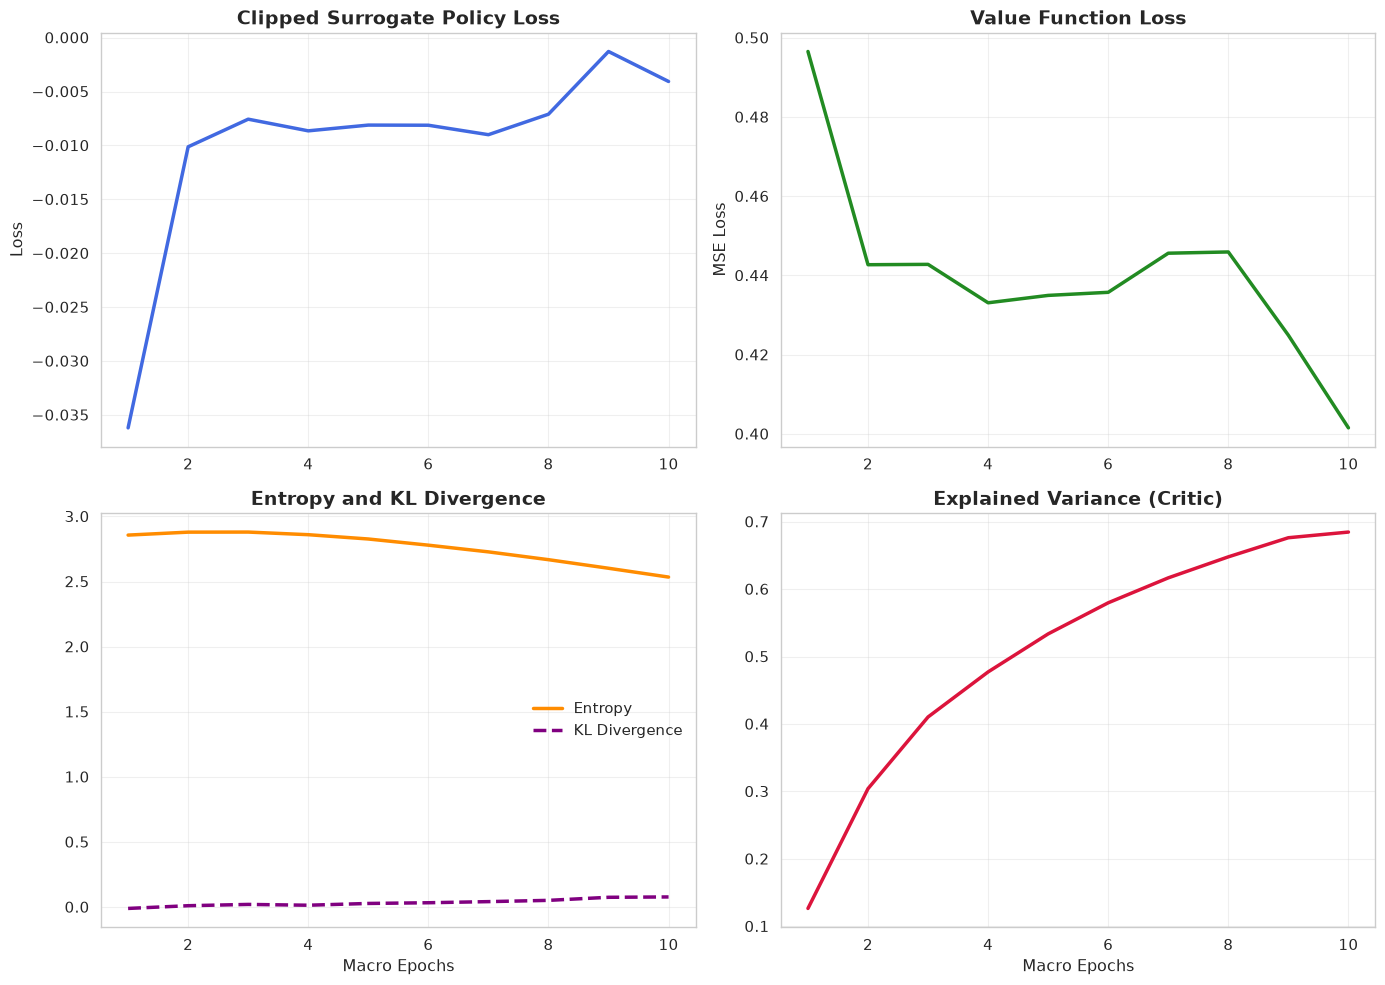

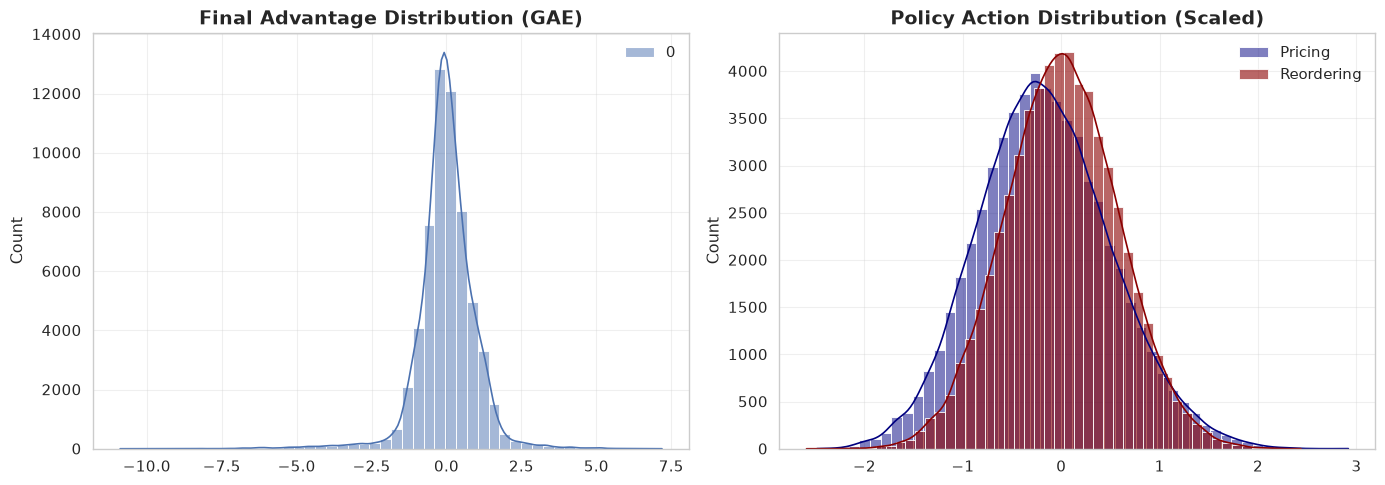

In [23]:
import seaborn as sns


def plot_cql_training_metrics(history):
    epochs = range(1, len(history["policy_loss"]) + 1)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Policy Loss
    sns.lineplot(
        x=epochs,
        y=history["policy_loss"],
        ax=axes[0, 0],
        color="royalblue",
        linewidth=2.5,
    )
    axes[0, 0].set_title(
        "Clipped Surrogate Policy Loss", fontsize=14, fontweight="bold"
    )
    axes[0, 0].set_ylabel("Loss")

    # Value Loss
    sns.lineplot(
        x=epochs,
        y=history["value_loss"],
        ax=axes[0, 1],
        color="forestgreen",
        linewidth=2.5,
    )
    axes[0, 1].set_title("Value Function Loss", fontsize=14, fontweight="bold")
    axes[0, 1].set_ylabel("MSE Loss")

    # Entropy & KL Divergence
    sns.lineplot(
        x=epochs,
        y=history["entropy"],
        ax=axes[1, 0],
        color="darkorange",
        linewidth=2.5,
        label="Entropy",
    )
    sns.lineplot(
        x=epochs,
        y=history["kl_div"],
        ax=axes[1, 0],
        color="purple",
        linewidth=2.5,
        label="KL Divergence",
        linestyle="--",
    )
    axes[1, 0].set_title("Entropy and KL Divergence", fontsize=14, fontweight="bold")
    axes[1, 0].set_xlabel("Macro Epochs")
    axes[1, 0].legend()

    # Explained Variance
    sns.lineplot(
        x=epochs,
        y=history["explained_variance"],
        ax=axes[1, 1],
        color="crimson",
        linewidth=2.5,
    )
    axes[1, 1].set_title("Explained Variance (Critic)", fontsize=14, fontweight="bold")
    axes[1, 1].set_xlabel("Macro Epochs")

    plt.tight_layout()
    plt.savefig("./plots/CQL_Training_Metrics.pdf", format="pdf", dpi=1200)
    plt.show()

    # Advantage and Action Distribution Plots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    sns.histplot(advantages.cpu().numpy(), bins=50, kde=True, ax=axes[0], color="teal")
    axes[0].set_title(
        "Final Advantage Distribution (GAE)", fontsize=14, fontweight="bold"
    )

    sns.histplot(
        A_pred_scaled[:, 0],
        bins=50,
        kde=True,
        ax=axes[1],
        color="navy",
        label="Pricing",
    )
    sns.histplot(
        A_pred_scaled[:, 1],
        bins=50,
        kde=True,
        ax=axes[1],
        color="darkred",
        label="Reordering",
        alpha=0.6,
    )
    axes[1].set_title(
        "Policy Action Distribution (Scaled)", fontsize=14, fontweight="bold"
    )
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("./plots/CQL_Distributions.pdf", format="pdf", dpi=1200)
    plt.show()


plot_cql_training_metrics(training_history)

#### Save the Final Surrogate Model


In [24]:
# torch.save(dqn_agent.state_dict(), "./model/CQL_dueling_drl.pth")
elapsed_time = time.time() - start_time
print(f"\nOffline Deep RL Training Completed in {elapsed_time / 60:.2f} minutes.")
# print("Models saved to './model/' directory.")


Offline Deep RL Training Completed in 2.15 minutes.


## Explainable AI (XRL) Generation


### Local Explanations via SHAP (Step-by-Step Inference)


#### PyTorch Model Wrapper for SHAP


In [25]:
# SHAP requires a model that takes an input tensor and returns a single output tensor.
# We wrap the CQL Actor to only return the deterministic mean action stream.
class ActionStreamWrapper(nn.Module):
    def __init__(self, actor_model):
        super(ActionStreamWrapper, self).__init__()
        self.model = actor_model

    def forward(self, x):
        mean, _ = self.model(x)
        return mean


action_model = ActionStreamWrapper(actor).to(device)
action_model.eval()

ActionStreamWrapper(
  (model): CQLActorNetwork(
    (net): Sequential(
      (0): Linear(in_features=46, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)

#### Prepare Background and Test Data


In [26]:
print("Preparing background distributions for SHAP...")

# SHAP calculates marginal contributions by comparing predictions against a "baseline" background.CQL
# We sample 200 random states from our normalized State matrix (S_matrix) as the background.CQL
rng = np.random.default_rng(42)
background_indices = rng.choice(S_matrix.shape[0], size=200, replace=False)
background_tensor = torch.tensor(S_matrix[background_indices], dtype=torch.float32).to(
    device
)

test_indices = np.arange(5)
test_tensor = torch.tensor(S_matrix[test_indices], dtype=torch.float32).to(device)

print("Preparing background distributions for SHAP completed successfully...")

Preparing background distributions for SHAP...
Preparing background distributions for SHAP completed successfully...


#### Initialize GradientExplainer & Compute SHAP


In [27]:
import shap

print("Initializing SHAP GradientExplainer...")
# GradientExplainer is highly stable for continuous PyTorch networks[cite: 1]
explainer = shap.GradientExplainer(action_model, background_tensor)

print("Calculating SHAP values for test instances...")
shap_values = explainer.shap_values(test_tensor)

# Ensure the output format matches expectations (List of arrays for each action dimension)[cite: 1]
if not isinstance(shap_values, list):
    shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

print("\nSHAP values successfully computed.")

Initializing SHAP GradientExplainer...
Calculating SHAP values for test instances...

SHAP values successfully computed.


#### Visualizing Local Explanations



Generating Local Explanation for Action: Price per Unit (sold) (Transaction #0)


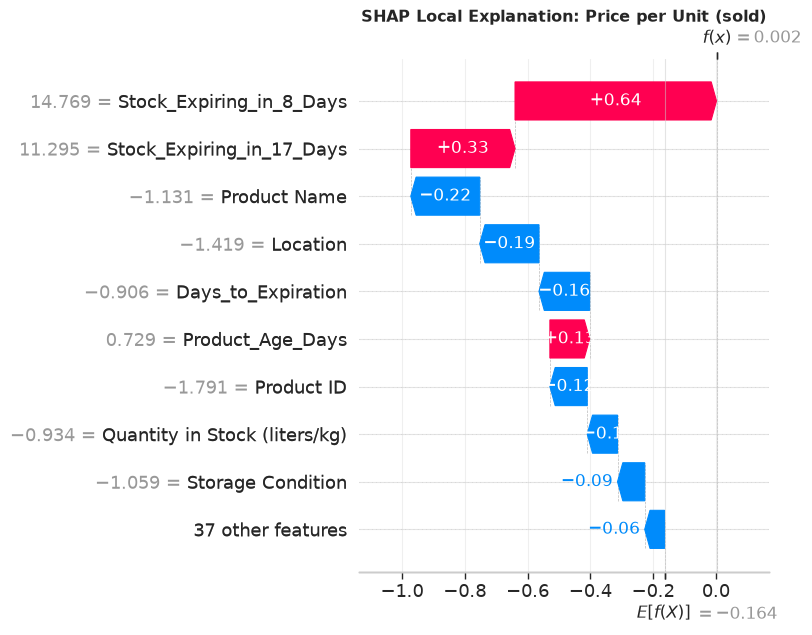


Generating Local Explanation for Action: Reorder Quantity (liters/kg) (Transaction #0)


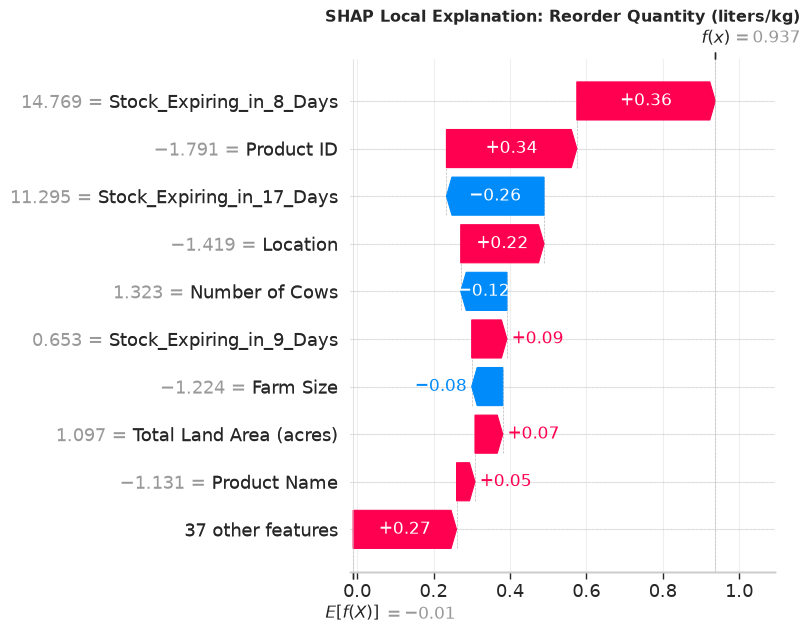

In [28]:
INSTANCE_IDX = 0
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(
        f"\nGenerating Local Explanation for Action: {action_name} (Transaction #{INSTANCE_IDX})"
    )

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        base_value = background_outputs[:, action_idx].mean().item()

    instance_shap_values = shap_values[action_idx][INSTANCE_IDX]
    instance_feature_values = S_matrix[INSTANCE_IDX]

    # Create an Explanation object for the waterfall plot[cite: 1]
    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=base_value,
        data=instance_feature_values,
        feature_names=state_cols,
    )

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Local Explanation: {action_name}")
    shap.waterfall_plot(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

#### Summary Profile



Generating Global Summary for 'Price per Unit (sold)' across test batch...


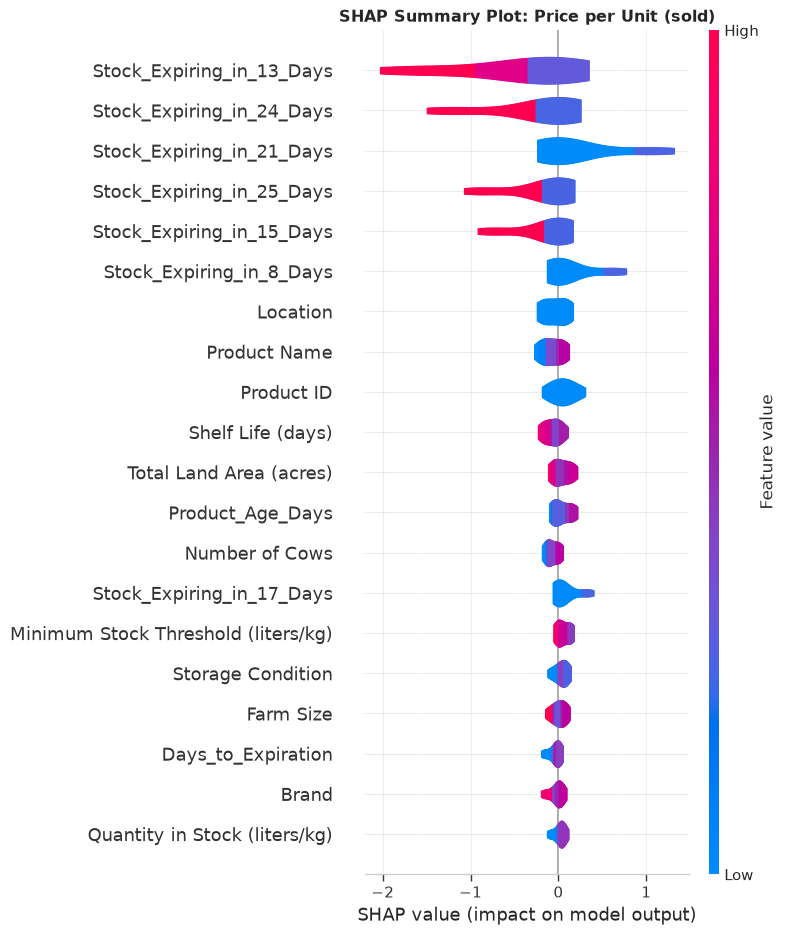

In [29]:
print("\nGenerating Global Summary for 'Price per Unit (sold)' across test batch...")
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot: {action_names[0]}")
shap.summary_plot(
    shap_values[0],
    test_tensor.cpu().numpy(),
    feature_names=state_cols,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Global Explanations via Symbolic Decision Trees


#### Train the Symbolic Surrogate Models


In [30]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

print("Training Surrogate Decision Trees on unscaled features...")
X_raw = rl_df_final[state_cols]

dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_price.fit(X_raw, A_pred_real[:, 0])

dt_reorder = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reorder.fit(X_raw, A_pred_real[:, 1])
print("Training Surrogate Decision Trees successfully...")

Training Surrogate Decision Trees on unscaled features...
Training Surrogate Decision Trees successfully...


#### Extract Human-Readable IF-THEN Rules


In [31]:
print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)")
print("-" * 60)
rules_price = export_text(dt_price, feature_names=list(X_raw.columns))
print(rules_price)

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: REORDER QUANTITY")
print("-" * 60)
rules_reorder = export_text(dt_reorder, feature_names=list(X_raw.columns))
print(rules_reorder)


------------------------------------------------------------
GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)
------------------------------------------------------------
|--- Price per Unit <= 68.62
|   |--- Price per Unit <= 48.03
|   |   |--- Stock_Expiring_in_10_Days <= 220.19
|   |   |   |--- value: [44.23]
|   |   |--- Stock_Expiring_in_10_Days >  220.19
|   |   |   |--- value: [21.67]
|   |--- Price per Unit >  48.03
|   |   |--- Stock_Expiring_in_18_Days <= 477.60
|   |   |   |--- value: [49.66]
|   |   |--- Stock_Expiring_in_18_Days >  477.60
|   |   |   |--- value: [16.64]
|--- Price per Unit >  68.62
|   |--- Price per Unit <= 84.71
|   |   |--- Stock_Expiring_in_5_Days <= 322.35
|   |   |   |--- value: [56.18]
|   |   |--- Stock_Expiring_in_5_Days >  322.35
|   |   |   |--- value: [21.40]
|   |--- Price per Unit >  84.71
|   |   |--- Product ID <= 10.00
|   |   |   |--- value: [64.49]
|   |   |--- Product ID >  10.00
|   |   |   |--- value: [46.45]


--------------------------

#### Evaluate Surrogate Fidelity ($R^2$ Score)


In [32]:
score_price = dt_price.score(X_raw, A_pred_real[:, 0])
score_inv = dt_reorder.score(X_raw, A_pred_real[:, 1])

print("\nSurrogate Fidelity Check (R^2 Score):")
print(f"-> Pricing Strategy Tree Fidelity: {score_price:.4f}")
print(f"-> Reorder Strategy Tree Fidelity: {score_inv:.4f}")

if score_price < 0.70 or score_inv < 0.70:
    print(
        "\n* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3)."
    )
    print(
        "  To increase fidelity, increase max_depth, though this will reduce human interpretability."
    )


Surrogate Fidelity Check (R^2 Score):
-> Pricing Strategy Tree Fidelity: 0.1906
-> Reorder Strategy Tree Fidelity: 0.0678

* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3).
  To increase fidelity, increase max_depth, though this will reduce human interpretability.


#### Visualizing the Strategy Tree



Generating Decision Tree Visualization for Pricing Strategy...


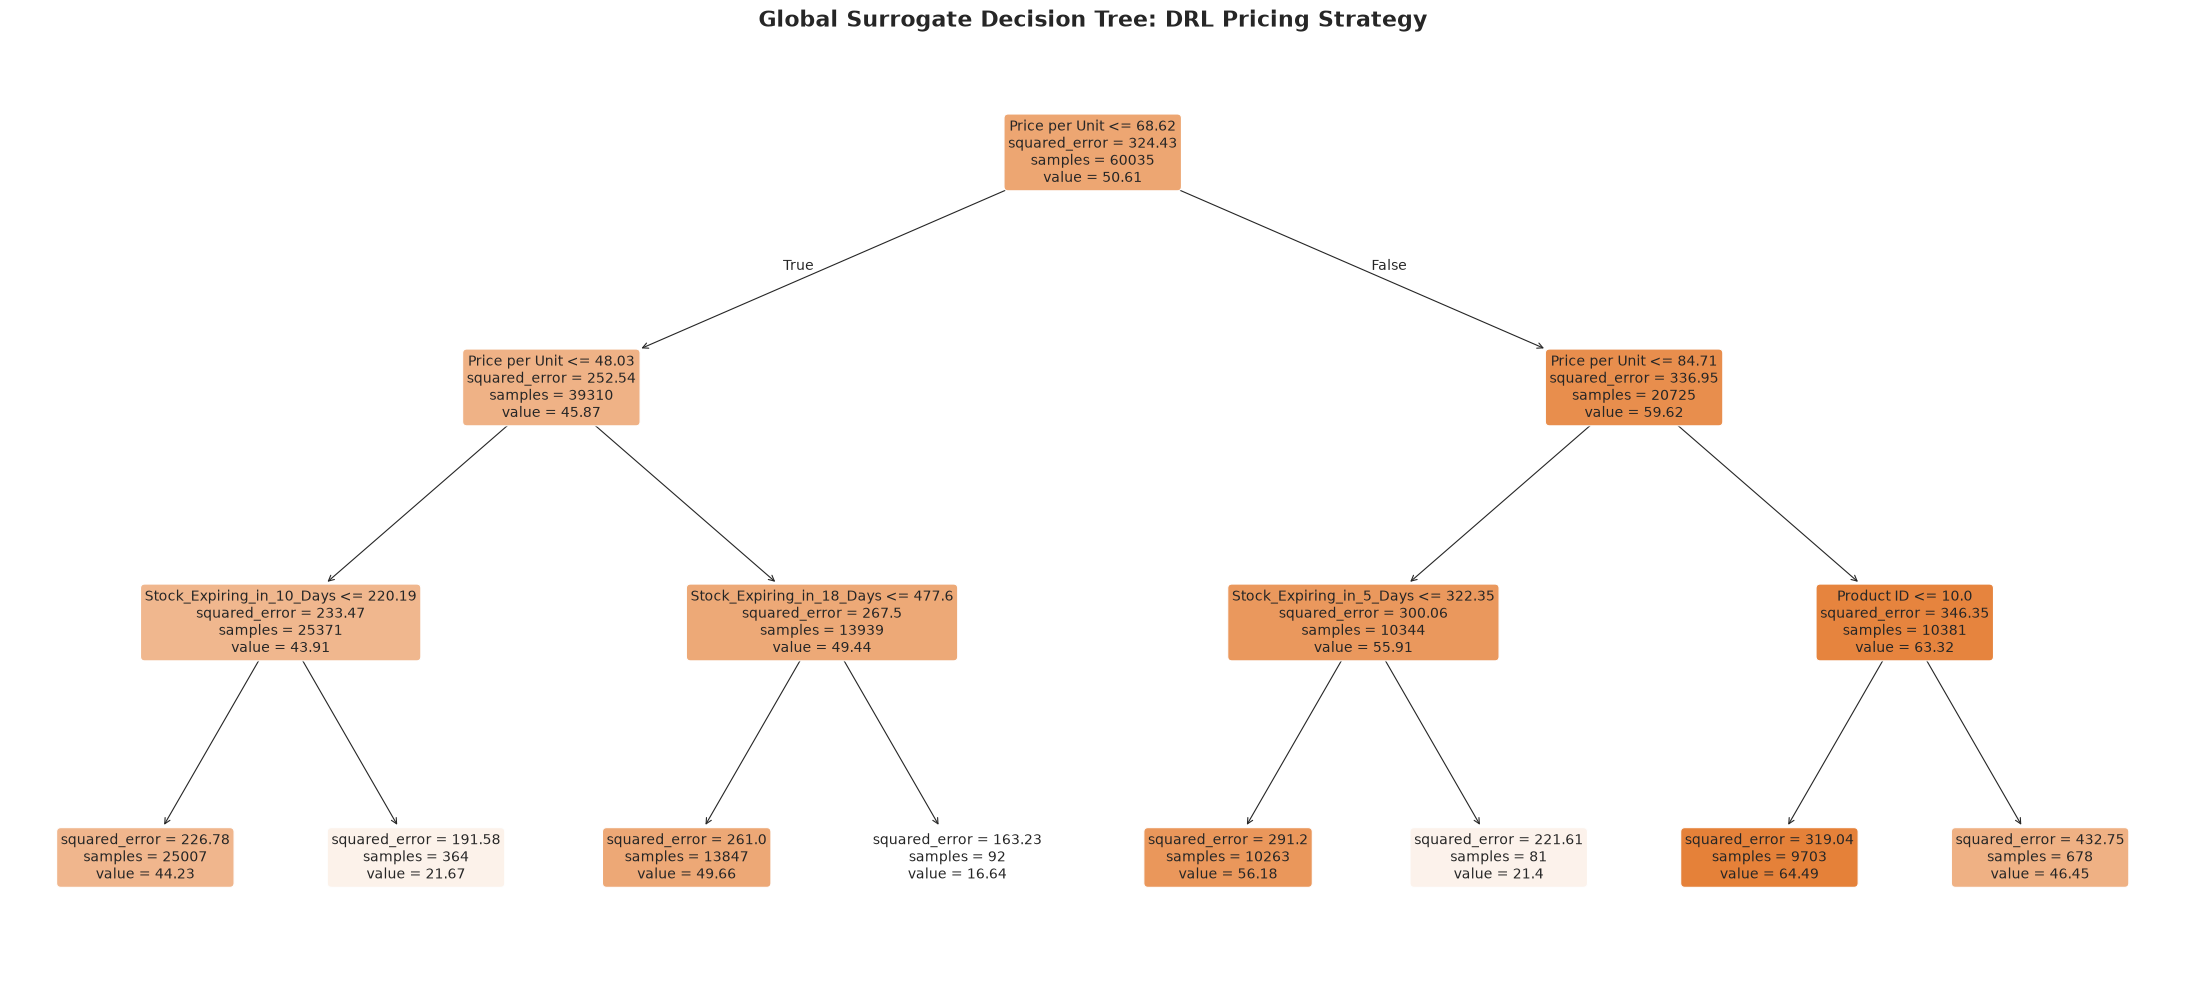

In [33]:
print("\nGenerating Decision Tree Visualization for Pricing Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_price,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Pricing Strategy", fontsize=16)
plt.tight_layout()
plt.show()


Generating Decision Tree Visualization for Reordering Strategy...


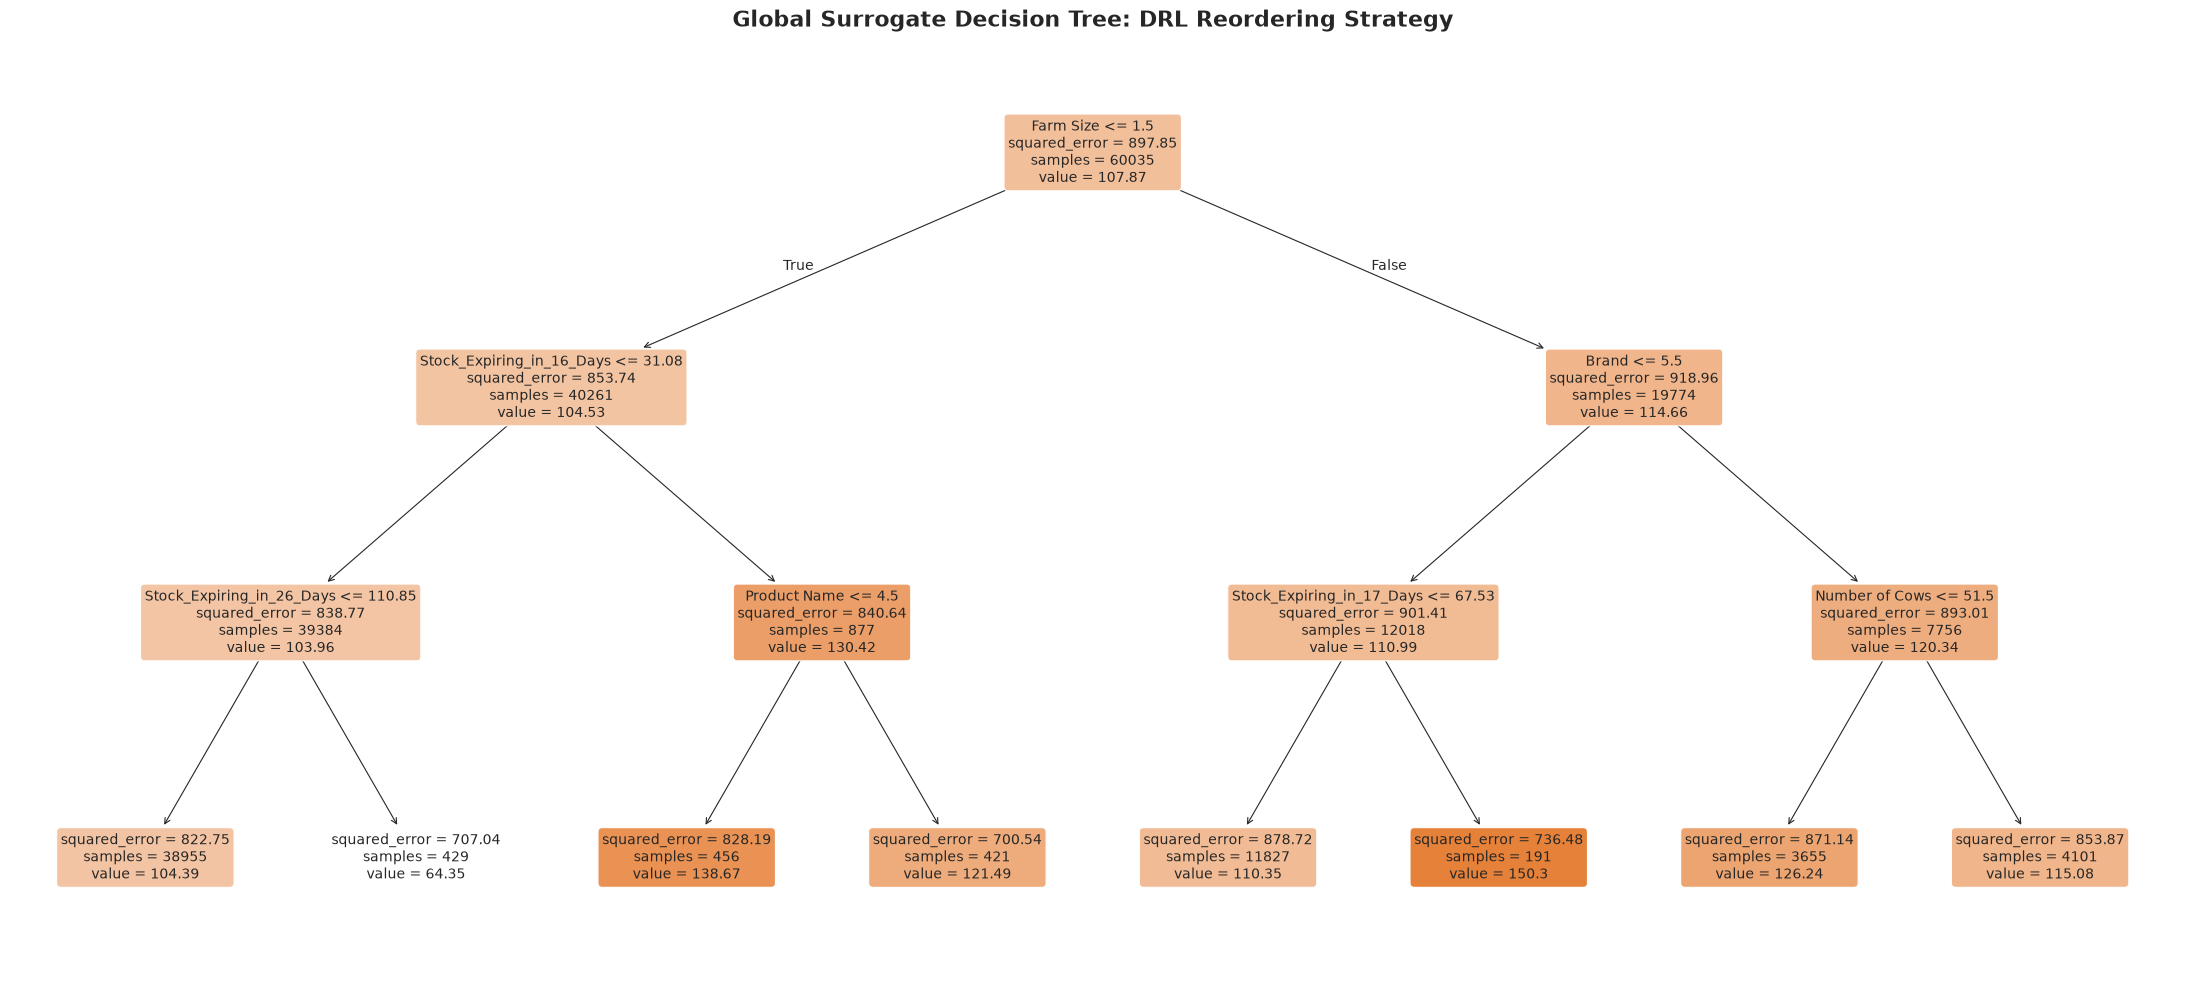

In [34]:
print("\nGenerating Decision Tree Visualization for Reordering Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_reorder,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Reordering Strategy", fontsize=16)
plt.tight_layout()
plt.show()

### Reward Decomposition (Post-Hoc Financial Surrogate)


#### Prepare Data for the Reward Surrogate


In [35]:
print("Preparing State-Action paired data...")
X_hist = np.hstack([S_matrix, A_matrix])
Y_hist = rl_df_final[
    ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
].values

X_agent_policy = np.hstack([S_matrix, A_pred_scaled])
feature_names_extended = state_cols + action_cols
print("Preparing State-Action paired data successfully...")

Preparing State-Action paired data...
Preparing State-Action paired data successfully...


#### Train the Multi-Output Reward Surrogate


In [36]:
from sklearn.ensemble import RandomForestRegressor

print("Training Multi-Output Random Forest Surrogate for Reward Decomposition...")
reward_surrogate = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
reward_surrogate.fit(X_hist, Y_hist)
print(
    "Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully..."
)

Training Multi-Output Random Forest Surrogate for Reward Decomposition...
Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully...


#### Predict Sub-Rewards for the Agent's Policy


In [37]:
print("Decomposing Agent's Expected Rewards...")
Y_agent_expected = reward_surrogate.predict(X_agent_policy)
print("Decomposing Agent's Expected Rewards successfully...")

Decomposing Agent's Expected Rewards...
Decomposing Agent's Expected Rewards successfully...


#### Visualizing Reward Decomposition for a Specific Transaction


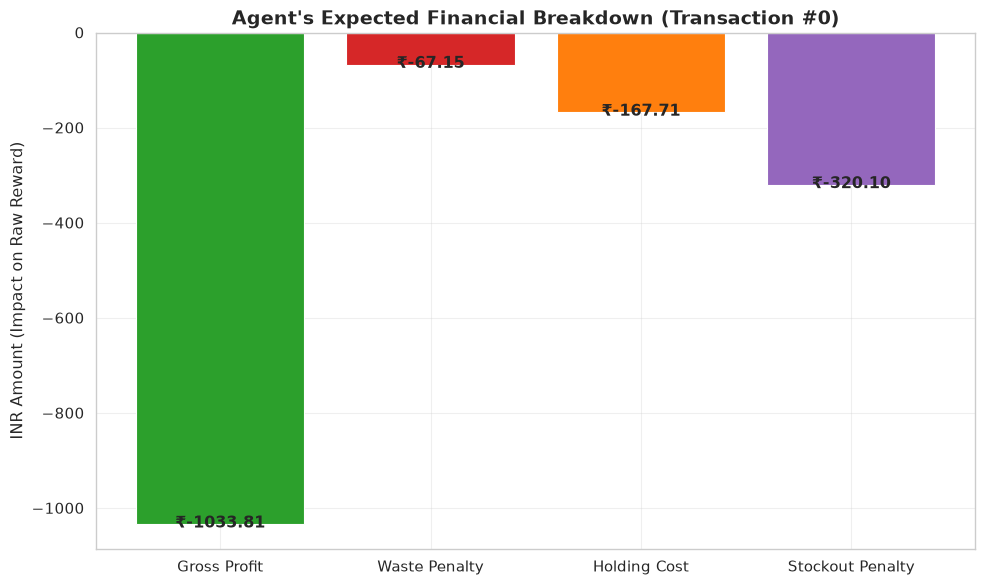

In [38]:
sub_rewards = Y_agent_expected[INSTANCE_IDX]

labels = ["Gross Profit", "Waste Penalty", "Holding Cost", "Stockout Penalty"]
values = [sub_rewards[0], -sub_rewards[1], -sub_rewards[2], -sub_rewards[3]]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1.2)
plt.title(
    f"Agent's Expected Financial Breakdown (Transaction #{INSTANCE_IDX})", fontsize=14
)
plt.ylabel("INR Amount (Impact on Raw Reward)")

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (5 if v > 0 else -15),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis: Isolating a Specific Objective (Waste Penalty)



Applying SHAP to explain how the Agent controls the 'Waste Penalty' Objective...


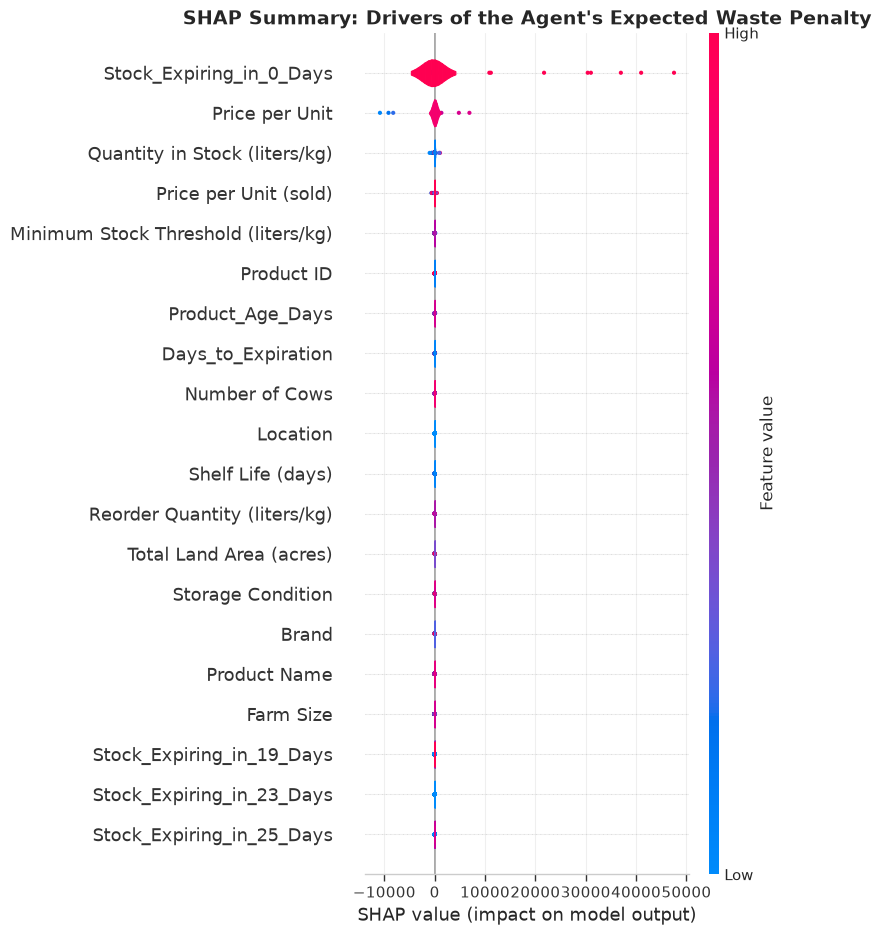

In [39]:
print(
    "\nApplying SHAP to explain how the Agent controls the 'Waste Penalty' Objective..."
)

tree_explainer = shap.TreeExplainer(reward_surrogate)

X_explain = X_agent_policy[:200]
shap_values_rf = tree_explainer.shap_values(X_explain)

if isinstance(shap_values_rf, list):
    waste_shap_values = shap_values_rf[1]
else:
    waste_shap_values = shap_values_rf[:, :, 1]

plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: Drivers of the Agent's Expected Waste Penalty", fontsize=14)
shap.summary_plot(
    waste_shap_values,
    X_explain,
    feature_names=feature_names_extended,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Post-Hoc XAI Evaluation & Validation


#### Global Fidelity vs. Interpretability Trade-Off


Evaluating Global Surrogate Fidelity across explanation complexities...


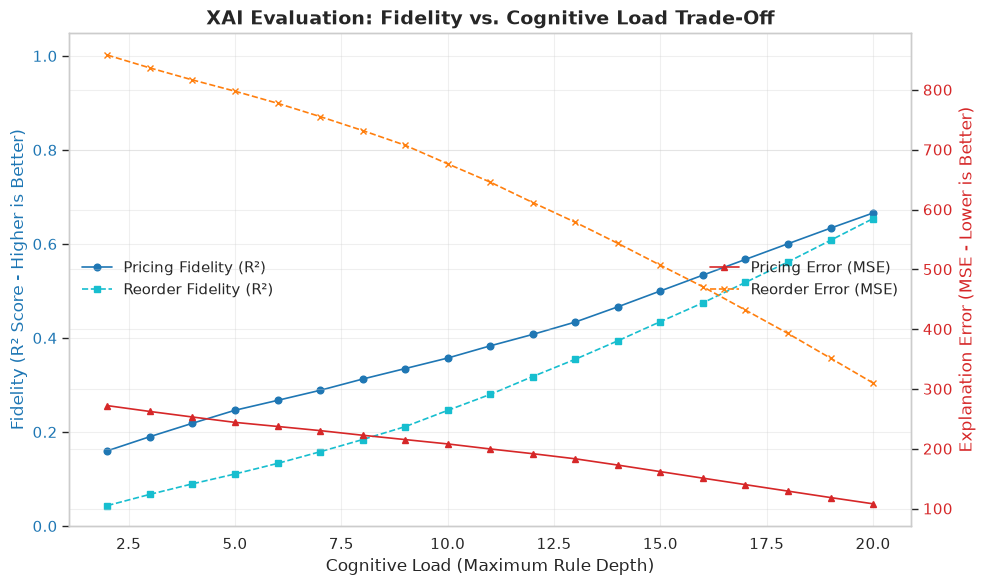

In [40]:
print("Evaluating Global Surrogate Fidelity across explanation complexities...")

depths = range(2, 21)
fidelity_r2_price = []
fidelity_r2_reorder = []
mse_price = []
mse_reorder = []

y_price = A_pred_real[:, 0]
y_reorder = A_pred_real[:, 1]

for d in depths:
    dt_p = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_p.fit(X_raw, y_price)
    preds_p = dt_p.predict(X_raw)
    fidelity_r2_price.append(r2_score(y_price, preds_p))
    mse_price.append(mean_squared_error(y_price, preds_p))

    dt_r = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_r.fit(X_raw, y_reorder)
    preds_r = dt_r.predict(X_raw)
    fidelity_r2_reorder.append(r2_score(y_reorder, preds_r))
    mse_reorder.append(mean_squared_error(y_reorder, preds_r))

# Plotting the Trade-off Curve
fig, ax1 = plt.subplots(figsize=(10, 6))
color1, color2 = "tab:blue", "tab:cyan"
ax1.set_xlabel("Cognitive Load (Maximum Rule Depth)", fontsize=12)
ax1.set_ylabel("Fidelity (R² Score - Higher is Better)", color=color1, fontsize=12)
ax1.plot(
    depths, fidelity_r2_price, marker="o", label="Pricing Fidelity (R²)", color=color1
)
ax1.plot(
    depths,
    fidelity_r2_reorder,
    marker="s",
    linestyle="--",
    label="Reorder Fidelity (R²)",
    color=color2,
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim((0, 1.05))
ax1.legend(loc="center left")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color3, color4 = "tab:red", "tab:orange"
ax2.set_ylabel("Explanation Error (MSE - Lower is Better)", color=color3, fontsize=12)
ax2.plot(depths, mse_price, marker="^", label="Pricing Error (MSE)", color=color3)
ax2.plot(
    depths,
    mse_reorder,
    marker="x",
    linestyle="--",
    label="Reorder Error (MSE)",
    color=color4,
)
ax2.tick_params(axis="y", labelcolor=color3)
ax2.legend(loc="center right")

plt.title("XAI Evaluation: Fidelity vs. Cognitive Load Trade-Off", fontsize=14)
fig.tight_layout()
plt.savefig("./plots/CQL_Fidelity_vs_Cognitive_Load.pdf", format="pdf", dpi=1200)
plt.show()

#### Local Fidelity (SHAP Completeness Axiom)


In [41]:
print("\nEvaluating Local Explanation Fidelity (SHAP Completeness Axiom)...")

local_fidelity_passed = True
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(f"\nVerifying Completeness for Action: {action_name}")

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        expected_val = background_outputs[:, action_idx].mean().item()
        actual_preds = action_model(test_tensor)[:, action_idx].cpu().numpy()

    shap_sums = shap_values[action_idx].sum(axis=1)

    for i in range(len(test_indices)):
        explanation_pred = shap_sums[i] + expected_val
        actual_pred = actual_preds[i]
        diff = abs(explanation_pred - actual_pred)

        print(
            f" Instance #{i} | Actual DRL Output: {actual_pred:.4f} | SHAP Explained Output: {explanation_pred:.4f} | Math Diff: {diff:.6f}"
        )

        if diff > 1e-4:
            local_fidelity_passed = False

if local_fidelity_passed:
    print(
        "\n[SUCCESS] Local Fidelity Check Passed: SHAP values strictly reconstruct the DRL agent's local decisions."
    )
else:
    print(
        "\n[WARNING] Local Fidelity Check Failed: SHAP explanations do not sum to the DRL output. The approximation is leaking information."
    )


Evaluating Local Explanation Fidelity (SHAP Completeness Axiom)...

Verifying Completeness for Action: Price per Unit (sold)
 Instance #0 | Actual DRL Output: 0.0369 | SHAP Explained Output: 0.0018 | Math Diff: 0.035120
 Instance #1 | Actual DRL Output: -0.1780 | SHAP Explained Output: -0.0977 | Math Diff: 0.080310
 Instance #2 | Actual DRL Output: -1.6326 | SHAP Explained Output: -1.9405 | Math Diff: 0.307937
 Instance #3 | Actual DRL Output: -1.5895 | SHAP Explained Output: -1.6634 | Math Diff: 0.073953
 Instance #4 | Actual DRL Output: -0.5578 | SHAP Explained Output: -0.5093 | Math Diff: 0.048495

Verifying Completeness for Action: Reorder Quantity (liters/kg)
 Instance #0 | Actual DRL Output: 0.8569 | SHAP Explained Output: 0.9375 | Math Diff: 0.080592
 Instance #1 | Actual DRL Output: -0.4516 | SHAP Explained Output: -0.5574 | Math Diff: 0.105777
 Instance #2 | Actual DRL Output: -0.5075 | SHAP Explained Output: -0.8539 | Math Diff: 0.346343
 Instance #3 | Actual DRL Output: -0.

### Selectivity & Perturbation (PI / Masking)


#### Identify Top and Bottom Features from SHAP


In [42]:
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)
sorted_feature_indices = np.argsort(mean_abs_shap)[::-1]

top_3_indices = sorted_feature_indices[:3]
top_3_features = [state_cols[i] for i in top_3_indices]
print(f"Top 3 Features identified by SHAP: \n{top_3_features}\n")

bottom_3_indices = sorted_feature_indices[-3:]
bottom_3_features = [state_cols[i] for i in bottom_3_indices]

Top 3 Features identified by SHAP: 
['Stock_Expiring_in_13_Days', 'Stock_Expiring_in_24_Days', 'Stock_Expiring_in_21_Days']



#### Collinearity Check


In [43]:
print("Executing Collinearity Check...")

for feat in top_3_features:
    corrs = []
    for f1, f2, val in collinear_pairs:
        if feat == f1:
            corrs.append(f2)
        elif feat == f2:
            corrs.append(f1)

    if corrs:
        print(
            f" [!] WARNING: '{feat}' is highly correlated with {corrs}. Masking it might trigger the agent to use the correlated proxy."
        )
    else:
        print(f" [OK] '{feat}' is independent. No collinearity detected.")

Executing Collinearity Check...
 [OK] 'Stock_Expiring_in_13_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_24_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_21_Days' is independent. No collinearity detected.


#### Permutation Importance / Masking Evaluation


In [44]:
print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    with torch.no_grad():
        print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")

        def evaluate_policy_reward(state_tensor):
            with torch.no_grad():
                pred_actions, _ = actor(state_tensor)

            X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
            sub_rewards = reward_surrogate.predict(X_eval)

            raw_rewards = (
                sub_rewards[:, 0]
                - sub_rewards[:, 1]
                - sub_rewards[:, 2]
                - sub_rewards[:, 3]
            )
            return raw_rewards.mean()

        baseline_reward = evaluate_policy_reward(test_tensor)
        print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

        perturbed_states_top = test_tensor.clone()
        for idx in top_3_indices:
            perturbed_states_top[:, idx] = 0.0

        degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
        drop_pct_top = (
            (baseline_reward - degraded_reward_top) / abs(baseline_reward)
        ) * 100
        print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
        print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

        print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
        perturbed_states_bottom = test_tensor.clone()
        for idx in bottom_3_indices:
            perturbed_states_bottom[:, idx] = 0.0

        degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
        drop_pct_bottom = (
            (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
        ) * 100
        print(
            f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}"
        )
        print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")

    print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")

    def evaluate_policy_reward(state_tensor):
        with torch.no_grad():
            pred_actions, _ = actor(state_tensor)

        X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
        sub_rewards = reward_surrogate.predict(X_eval)

        raw_rewards = (
            sub_rewards[:, 0]
            - sub_rewards[:, 1]
            - sub_rewards[:, 2]
            - sub_rewards[:, 3]
        )
        return raw_rewards.mean()

    baseline_reward = evaluate_policy_reward(test_tensor)
    print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

    perturbed_states_top = test_tensor.clone()
    for idx in top_3_indices:
        perturbed_states_top[:, idx] = 0.0

    degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
    drop_pct_top = (
        (baseline_reward - degraded_reward_top) / abs(baseline_reward)
    ) * 100
    print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
    print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

    print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
    perturbed_states_bottom = test_tensor.clone()
    for idx in bottom_3_indices:
        perturbed_states_bottom[:, idx] = 0.0

    degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
    drop_pct_bottom = (
        (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
    ) * 100
    print(
        f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}"
    )
    print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")
    sub_rewards = reward_surrogate.predict(X_eval)

    raw_rewards = (
        sub_rewards[:, 0] - sub_rewards[:, 1] - sub_rewards[:, 2] - sub_rewards[:, 3]
    )
    return raw_rewards.mean()


print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    with torch.no_grad():
        pred_actions, _ = actor(state_tensor)

        X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
        sub_rewards = reward_surrogate.predict(X_eval)

        raw_rewards = (
            sub_rewards[:, 0]
            - sub_rewards[:, 1]
            - sub_rewards[:, 2]
            - sub_rewards[:, 3]
        )
        return raw_rewards.mean()


baseline_reward = evaluate_policy_reward(test_tensor)
print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

perturbed_states_top = test_tensor.clone()
for idx in top_3_indices:
    perturbed_states_top[:, idx] = 0.0

degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
drop_pct_top = ((baseline_reward - degraded_reward_top) / abs(baseline_reward)) * 100
print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
perturbed_states_bottom = test_tensor.clone()
for idx in bottom_3_indices:
    perturbed_states_bottom[:, idx] = 0.0

degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
drop_pct_bottom = (
    (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
) * 100
print(f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}")
print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")


Evaluating Agent Performance Drop (Perturbation Importance)...

Evaluating Agent Performance Drop (Perturbation Importance)...
-> Baseline Expected Reward (Unperturbed): ₹-2652.33
-> Expected Reward (Top 3 Features Masked): ₹-2660.01
-> Performance Impact: 0.29% drop

Sanity Check: Masking Bottom 3 Features 
['Stock_Expiring_in_28_Days', 'Stock_Expiring_in_14_Days', 'Stock_Expiring_in_23_Days']...
-> Expected Reward (Bottom 3 Features Masked): ₹-2652.33
-> Performance Impact: 0.00% drop


#### Visualization of Performance Degradation


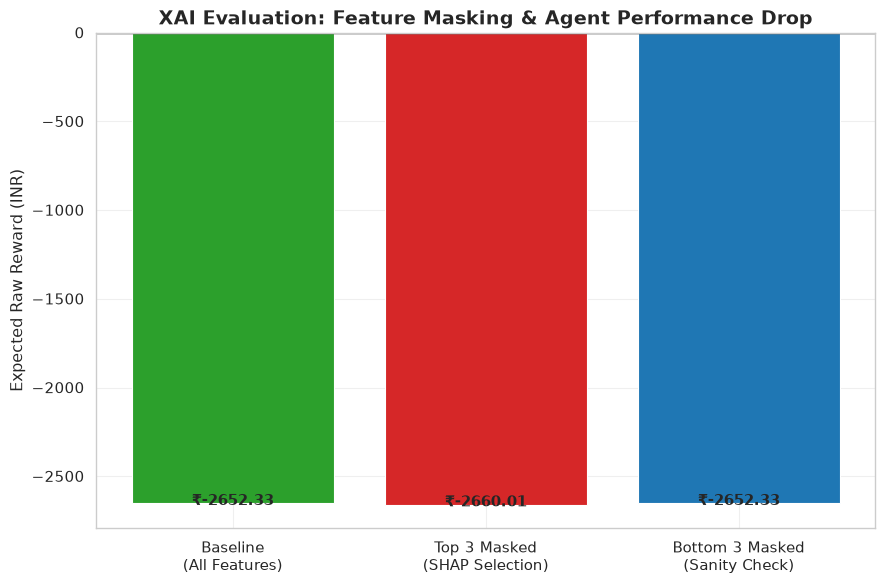

In [45]:
labels = [
    "Baseline\n(All Features)",
    "Top 3 Masked\n(SHAP Selection)",
    "Bottom 3 Masked\n(Sanity Check)",
]
values = [baseline_reward, degraded_reward_top, degraded_reward_bottom]
colors = ["#2ca02c", "#d62728", "#1f77b4"]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)
plt.title("XAI Evaluation: Feature Masking & Agent Performance Drop", fontsize=14)
plt.ylabel("Expected Raw Reward (INR)")
plt.axhline(0, color="black", linewidth=1)

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (10 if v > 0 else -30),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### Stability & Robustness Profiling (Lipschitz Continuity)


#### Generate Local Perturbations (Noise Injection)


In [46]:
print("Generating 100 near-identical state transitions...")
NUM_SAMPLES = 100
ACTION_IDX = 0

base_state = S_matrix[INSTANCE_IDX]

np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=0.01, size=(NUM_SAMPLES, STATE_DIM))
perturbed_states = base_state + noise

perturbed_states[0] = base_state
perturbed_tensor = torch.tensor(perturbed_states, dtype=torch.float32).to(device)

Generating 100 near-identical state transitions...


#### Extract SHAP Explanations for Perturbed States


In [47]:
print("Calculating SHAP values for perturbed states...")
shap_values_perturbed = explainer.shap_values(perturbed_tensor)

if isinstance(shap_values_perturbed, list):
    shap_action_perturbed = shap_values_perturbed[ACTION_IDX]
else:
    shap_action_perturbed = shap_values_perturbed[:, :, ACTION_IDX]

base_shap = shap_action_perturbed[0]

Calculating SHAP values for perturbed states...


#### Calculate Lipschitz Continuity and Variance


In [48]:
from scipy.spatial.distance import cdist

print("Calculating Lipschitz constants and feature-wise variance...")

dx = cdist([base_state], perturbed_states, metric="euclidean")[0] + 1e-9
de = cdist([base_shap], shap_action_perturbed, metric="euclidean")[0]

lipschitz_ratios = de / dx
local_lipschitz_constant = np.max(lipschitz_ratios[1:])

shap_variances = np.var(shap_action_perturbed, axis=0)

print("\nStability Metrics:")
print("-" * 60)
print(f"-> Local Lipschitz Constant (L): {local_lipschitz_constant:.4f}")
if local_lipschitz_constant < 5.0:
    print(
        "   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy."
    )
else:
    print(
        "   [WARNING] High Lipschitz constant. The explanations are fragile to noise."
    )

Calculating Lipschitz constants and feature-wise variance...

Stability Metrics:
------------------------------------------------------------
-> Local Lipschitz Constant (L): 9.9286
   [WARNING] High Lipschitz constant. The explanations are fragile to noise.


#### Visualization of XAI Robustness



Generating Robustness Profile Visualizations...


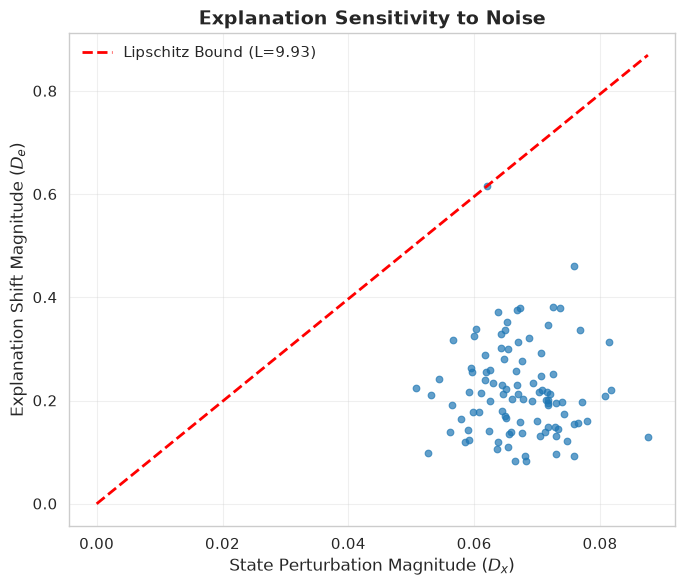

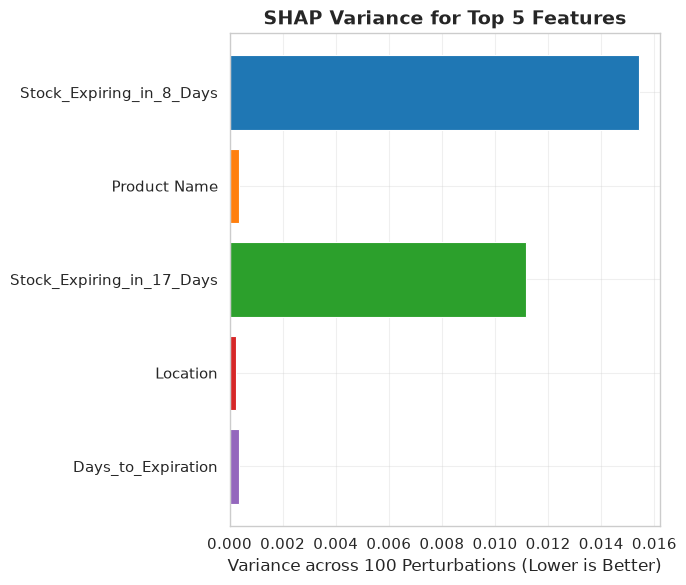

In [49]:
print("\nGenerating Robustness Profile Visualizations...")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

ax.scatter(dx[1:], de[1:], alpha=0.7, color="#1f77b4")
ax.set_title("Explanation Sensitivity to Noise", fontsize=14)
ax.set_xlabel(r"State Perturbation Magnitude ($D_x$)", fontsize=12)
ax.set_ylabel(r"Explanation Shift Magnitude ($D_e$)", fontsize=12)
ax.grid(alpha=0.3)

x_vals = np.linspace(0, np.max(dx), 100)
y_vals = local_lipschitz_constant * x_vals

ax.plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Lipschitz Bound (L={local_lipschitz_constant:.2f})",
)
ax.legend()

plt.tight_layout()
plt.savefig(
    "./plots/CQL_Explanation_Sensitivity_to_Noise.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

top_5_indices = np.argsort(np.abs(base_shap))[::-1][:5]
top_5_features = [state_cols[i] for i in top_5_indices]
top_5_variances = shap_variances[top_5_indices]

ax.barh(
    top_5_features[::-1],
    top_5_variances[::-1],
    color=["#9467bd", "#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"],
)
ax.set_title("SHAP Variance for Top 5 Features", fontsize=14)
ax.set_xlabel("Variance across 100 Perturbations (Lower is Better)", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./plots/CQL_SHAP_Variance_Top5_Features.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Architectural Metric Summary


In [50]:
import pandas as pd

CQL_data = {
    "Average Reward": f"{A_pred_scaled.mean():.4f}",
    "Policy Loss": f"{training_history['policy_loss'][-1]:.4f}",
    "Value Loss": f"{training_history['value_loss'][-1]:.4f}",
    "MAE": f"{p_mae:.4f}",
    "RMSE": f"{p_rmse:.4f}",
    "R²": f"{p_r2:.4f}",
    "Pricing Accuracy": f"{p_acc:.2f}%",
    "Reordering Accuracy": f"{r_acc:.2f}%",
    "Overall DRL Accuracy": f"{overall_drl_acc:.2f}%",
    "Training Time": f"{elapsed_time:.2f} sec",
    "Pricing Strategy Tree Fidelity (Depth=3)": f"{score_price * 100:.2f}%",
    "Reorder Strategy Tree Fidelity (Depth=3)": f"{score_inv * 100:.2f}%",
    "Baseline Expected Reward (Unperturbed)": f"₹{baseline_reward:.2f}",
    "Expected Reward (Top 3 Features Masked)": f"₹{degraded_reward_top:.2f}",
    "Expected Reward (Bottom 3 Features Masked):": f"₹{degraded_reward_bottom:.2f}",
    "Performance Impact (Top 3 Features Masked)": f"{drop_pct_top:.2f}%",
    "Performance Impact (Bottom 3 Features Masked)": f"{drop_pct_bottom:.2f}%",
    "Lipschitz Constant": local_lipschitz_constant,
}

CQL_df = pd.DataFrame([CQL_data], index=["CQL"]).T
CQL_df.to_csv("./results/CQL_df.csv", index=True)
CQL_df

,CQL
Average Reward,-0.0798
Policy Loss,-0.0041
Value Loss,0.4015
MAE,21.1547
RMSE,26.0593
R²,0.0361
Pricing Accuracy,73.76%
Reordering Accuracy,66.65%
Overall DRL Accuracy,70.20%
Training Time,128.99 sec
